# 04 — Evaluation
WBC Classification · EfficientNetB3

**Run this notebook only after training is complete.**
The test set should be touched exactly once — here.

Outputs:
- Normalised confusion matrix
- Per-class precision / recall / F1
- Grad-CAM visualisations (3 samples per class)
- Misclassification analysis

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from pathlib import Path

from dataset import build_dataset, CLASSES, NUM_CLASSES
from utils   import evaluate_model, plot_confusion_matrix, save_gradcam_grid

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

DATA_DIR    = Path('../data/processed')
MODELS_DIR  = Path('../models/final')
RESULTS_DIR = Path('../results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE  = 32

## Load Model

In [2]:
model_path = MODELS_DIR / 'efficientnetb3_wbc_final.keras'
model = tf.keras.models.load_model(model_path)
print(f'Model loaded from: {model_path}')
model.summary(line_length=80, expand_nested=False)

Model loaded from: ..\models\final\efficientnetb3_wbc_final.keras
Model: "EfficientNetB3_WBC"
________________________________________________________________________________
 Layer (type)                       Output Shape                    Param #     
 input_image (InputLayer)           [(None, 300, 300, 3)]           0           
                                                                                
 efficientnetb3 (Functional)        (None, 10, 10, 1536)            10783535    
                                                                                
 gap (GlobalAveragePooling2D)       (None, 1536)                    0           
                                                                                
 bn_head (BatchNormalization)       (None, 1536)                    6144        
                                                                                
 dropout_1 (Dropout)                (None, 1536)                    0           
               

## Load Test Set (do not shuffle!)

In [3]:
test_ds = build_dataset(
    DATA_DIR / 'test',
    batch_size=BATCH_SIZE,
    augment=False,
    shuffle=False,   # Must be False for y_true to align with y_pred
    cache=False,     # Safe to keep False for test — only run once
)

[dataset] test: 3212 images across 9 classes


## Full Evaluation (confusion matrix + classification report)

                     precision    recall  f1-score   support

          Basophile     1.0000    0.9757    0.9877       206
        Eosinophile     0.9082    0.8725    0.8900       204
        Lymphoblast     0.9215    0.9863    0.9528       512
         Lymphocyte     0.9520    0.9754    0.9636       610
           Monocyte     0.9453    0.9314    0.9383       408
         Myeloblast     0.9809    0.9114    0.9449       508
   Neutrophile_Band     0.8571    0.2857    0.4286        21
Neutrophile_Segment     0.9515    0.9797    0.9654       641
         Normoblast     0.9604    0.9510    0.9557       102

           accuracy                         0.9505      3212
          macro avg     0.9419    0.8744    0.8919      3212
       weighted avg     0.9507    0.9505    0.9492      3212

[utils] Report saved → ..\results\classification_report.csv
[utils] Confusion matrix saved → ..\results\confusion_matrix.png


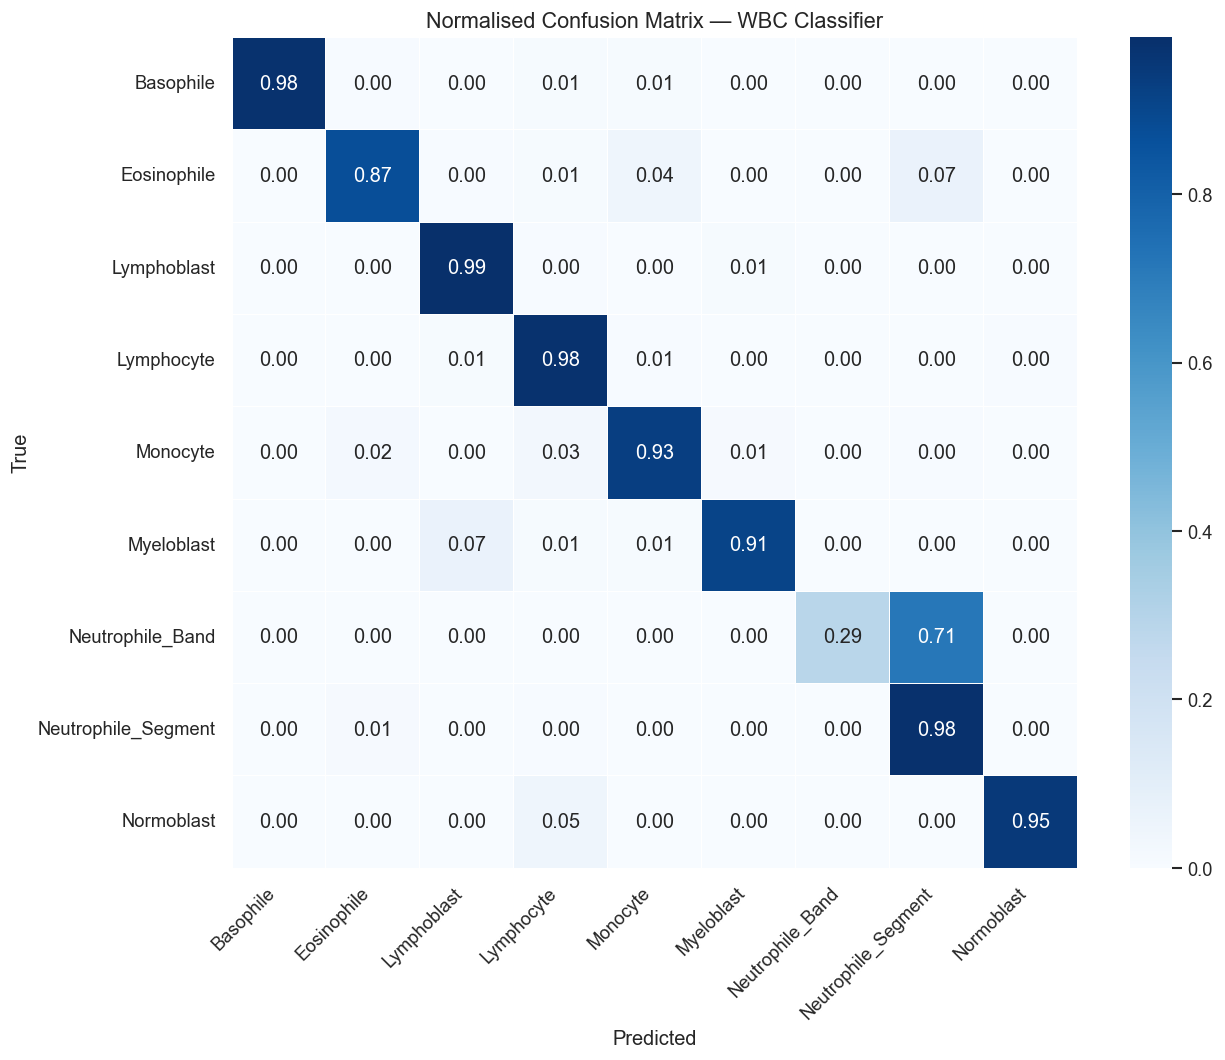

In [4]:
y_true, y_pred = evaluate_model(model, test_ds, save_dir=RESULTS_DIR)

## Misclassification Analysis
Which pairs of classes confuse the model most?

In [5]:
from sklearn.metrics import confusion_matrix
import itertools

cm = confusion_matrix(y_true, y_pred)

# Off-diagonal entries sorted by frequency
errors = []
for i, j in itertools.product(range(NUM_CLASSES), range(NUM_CLASSES)):
    if i != j and cm[i, j] > 0:
        errors.append({
            'true':      CLASSES[i],
            'predicted': CLASSES[j],
            'count':     cm[i, j],
            'pct_of_true': cm[i, j] / cm[i].sum(),
        })

errors_df = pd.DataFrame(errors).sort_values('count', ascending=False)
print('Top misclassifications:')
display(errors_df.head(15))

Top misclassifications:


,true,predicted,count,pct_of_true
20,Myeloblast,Lymphoblast,35,0.068898
24,Neutrophile_Band,Neutrophile_Segment,15,0.714286
6,Eosinophile,Neutrophile_Segment,14,0.068627
17,Monocyte,Lymphocyte,12,0.029412
5,Eosinophile,Monocyte,9,0.044118
15,Monocyte,Eosinophile,8,0.019608
25,Neutrophile_Segment,Eosinophile,8,0.012480
11,Lymphocyte,Lymphoblast,6,0.009836
22,Myeloblast,Monocyte,5,0.009843
18,Monocyte,Myeloblast,5,0.012255


## Per-Class Metrics Bar Chart

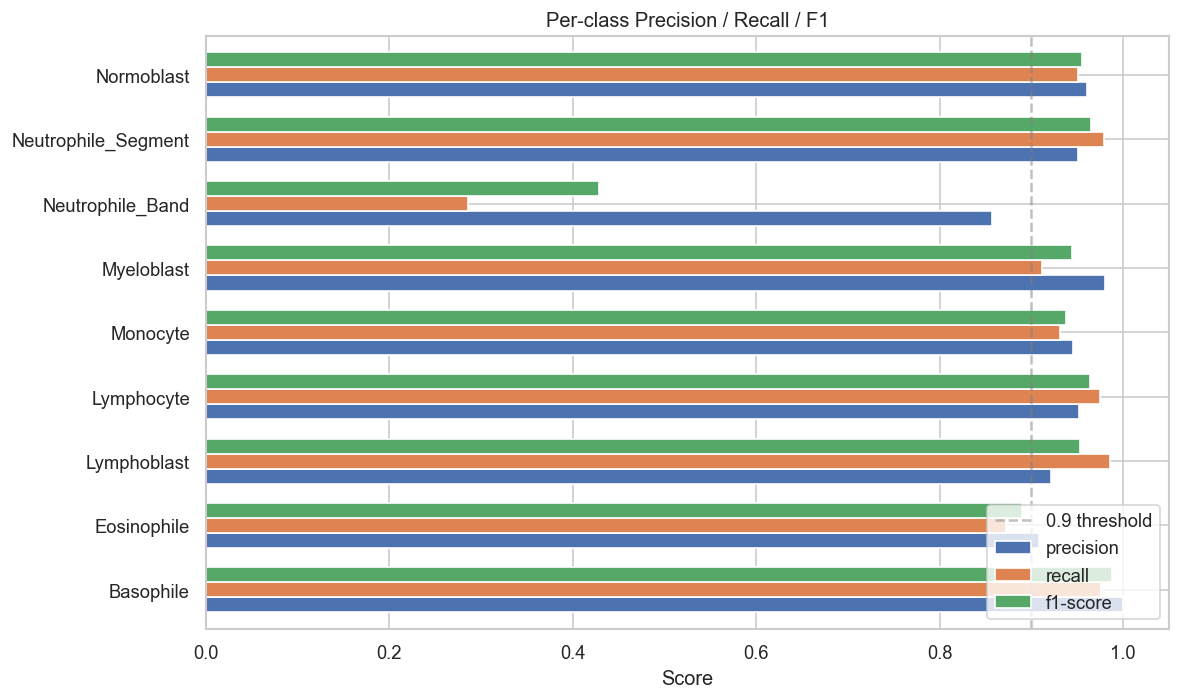

In [6]:
report_path = RESULTS_DIR / 'classification_report.csv'
report_df   = pd.read_csv(report_path, index_col=0)

# Extract per-class rows only
per_class = report_df.loc[CLASSES, ['precision', 'recall', 'f1-score']]

ax = per_class.plot(kind='barh', figsize=(10, 6), width=0.7)
ax.set_xlabel('Score')
ax.set_title('Per-class Precision / Recall / F1', fontsize=12)
ax.set_xlim(0, 1.05)
ax.axvline(0.9, color='gray', linestyle='--', alpha=0.5, label='0.9 threshold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'per_class_metrics.png', bbox_inches='tight')
plt.show()

## Grad-CAM Visualisations
Verifies the model is attending to morphological features (nucleus, cytoplasm)
rather than staining artefacts or background.

In [ ]:
# Reload test_ds without cache for Grad-CAM (we need numpy arrays)
test_ds_gradcam = build_dataset(
    DATA_DIR / 'test',
    batch_size=16,
    augment=False,
    shuffle=True,   # Shuffle here so we get varied samples per class
    cache=False,
)

save_gradcam_grid(
    model=model,
    dataset=test_ds_gradcam,
    save_dir=RESULTS_DIR / 'gradcam',
    n_per_class=3,
    last_conv_layer='top_conv',  # EfficientNetB3 last conv layer name
)
print('\nGrad-CAM images saved to results/gradcam/')

## Summary

In [8]:
test_loss, test_acc, test_auc = model.evaluate(test_ds, verbose=0)

macro_f1 = report_df.loc['macro avg', 'f1-score']
weighted_f1 = report_df.loc['weighted avg', 'f1-score']

print('=' * 45)
print('  Final Test Set Results')
print('=' * 45)
print(f'  Accuracy     : {test_acc:.4f}')
print(f'  AUC          : {test_auc:.4f}')
print(f'  Macro F1     : {macro_f1:.4f}')
print(f'  Weighted F1  : {weighted_f1:.4f}')
print(f'  Loss         : {test_loss:.4f}')
print('=' * 45)

  Final Test Set Results
  Accuracy     : 0.9505
  AUC          : 0.9974
  Macro F1     : 0.8919
  Weighted F1  : 0.9492
  Loss         : 0.2473
